In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from selfrf.utils.visualizer import visualize_batch
from selfrf.pretraining.factories import build_dataloader
from selfrf.pretraining.config import TrainingConfig
from selfrf.pretraining.utils.enums import DatasetType, SSLModelType

0it [00:00, ?it/s]

In [3]:
ROOT = Path("../datasets")

# BYOL

In [5]:
byol_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    spectrogram=True,
    ssl_model=SSLModelType.BYOL,
    num_workers=0,
    batch_size=1,
    nfft=512,
)

byol_narrowband_config = TrainingConfig(
    root=ROOT ,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=True,
    ssl_model=SSLModelType.BYOL,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

Wideband

In [5]:
datamodule = build_dataloader(byol_wideband_config)
datamodule.prepare_data()
datamodule.setup("fit")

Train Dataset: Wideband, Impairment Level 2, 5000 samples
Dataset exists at ../datasets/torchsig_wideband_impaired/train but is different than current dataset.
Differences:
	seed = 1679005854764738845 (404951623201600874 found)
If you want to overwrite dataset on disk, set overwrite = True for the DatasetCreator.
Not regenerating. Using dataset on disk.
Val Dataset: Wideband, Impairment Level 2, 500 samples
Dataset exists at ../datasets/torchsig_wideband_impaired/val but is different than current dataset.
Differences:
	seed = 13987271738230088056 (10153248197645300753 found)
If you want to overwrite dataset on disk, set overwrite = True for the DatasetCreator.
Not regenerating. Using dataset on disk.


In [6]:
loader = datamodule.train_dataloader()
batch = next(iter(loader))
visualize_batch(batch, mode="spectrogram")


KeyError: '1181'

Narrowband

In [6]:
print("🧠 SSL model:", type(byol_narrowband_config.ssl_model), byol_narrowband_config.ssl_model)

datamodule = build_dataloader(byol_narrowband_config)
print(f"🧪 Using DataModule: {type(datamodule)}")
print(f"🧪 Dataset type: {byol_narrowband_config.dataset}")
print(f"🧪 Dataset root path: {byol_narrowband_config.root}")

datamodule.prepare_data()

datamodule.setup("fit")

🧠 SSL model: <enum 'SSLModelType'> SSLModelType.BYOL
[DEBUG] Building collate function. Is validation: False
[DEBUG] Using MultiViewCollate
[DEBUG] Building collate function. Is validation: True
[DEBUG] Using MultiViewCollate
🧪 Using DataModule: <class 'selfrf.data.iqdm.iqdm_modules.IQDMNarrowbandDataModule'>
🧪 Dataset type: DatasetType.IQDM_NARROWBAND
🧪 Dataset root path: ../datasets


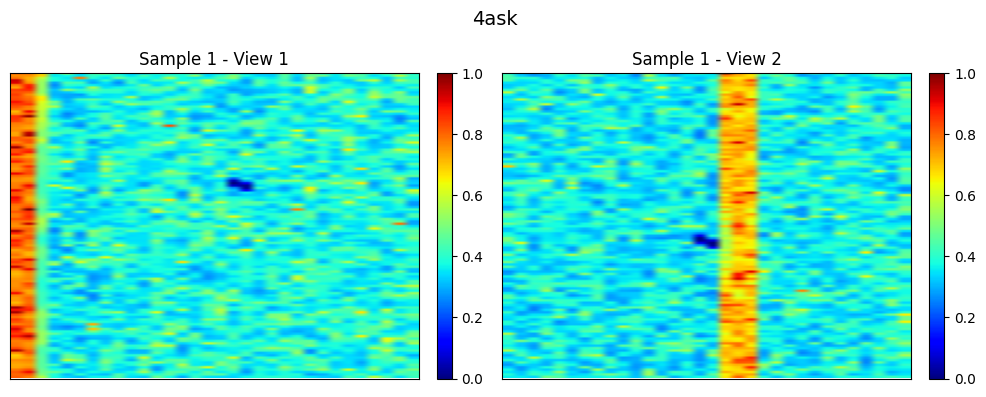

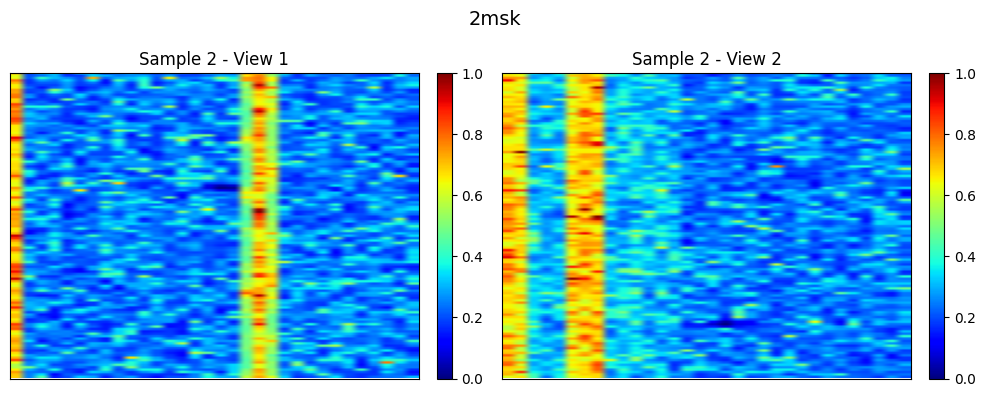

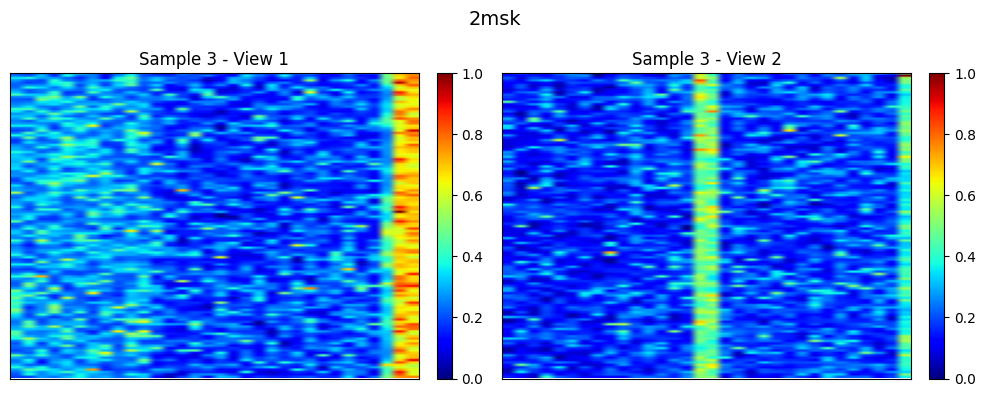

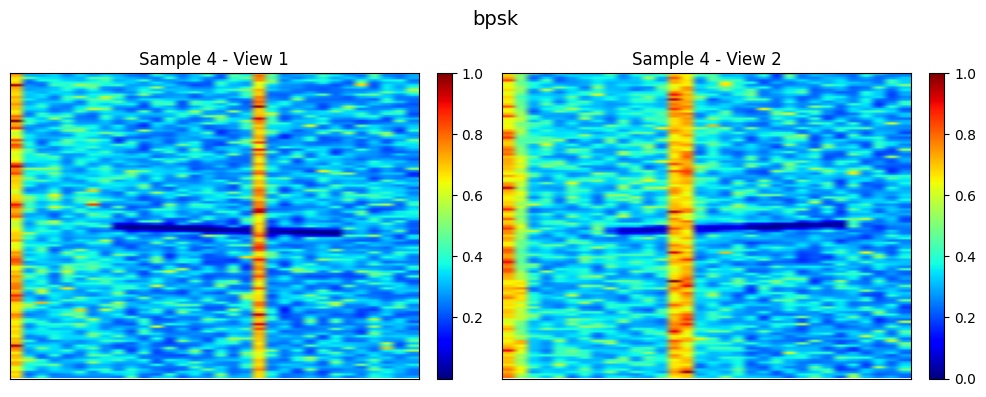

In [7]:
#datamodule.num_workers = 0
loader = datamodule.train_dataloader()
batch = next(iter(loader))
visualize_batch(batch, mode="spectrogram")

# DenseCL

In [ ]:
densecl_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    download=False,
    spectrogram=True,
    ssl_model=SSLModelType.DENSECL,
    batch_size=2,
    nfft=512,
    num_samples=10,
)

densecl_narrowband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_NARROWBAND,
    download=True,
    spectrogram=True,
    ssl_model=SSLModelType.DENSECL,
    batch_size=2,
    nfft=256,
)

In [ ]:
datamodule = build_dataloader(densecl_wideband_config)
datamodule.prepare_data()
datamodule.setup("fit")

In [ ]:
visualize(10, datamodule.train_dataloader())

In [ ]:
datamodule = build_dataloader(densecl_narrowband_config)
datamodule.prepare_data()
datamodule.setup("fit")

In [ ]:
visualize(10, datamodule.train_dataloader())

## DINO

In [7]:
dino_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    spectrogram=True,
    ssl_model=SSLModelType.DINO,
    num_workers=0,
    batch_size=1,
    nfft=512,
)

dino_narrowband_config = TrainingConfig(
    root=ROOT ,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=True,
    ssl_model=SSLModelType.DINO,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

Narrowband

In [8]:
print("🧠 SSL model:", type(dino_narrowband_config.ssl_model), dino_narrowband_config.ssl_model)

datamodule = build_dataloader(dino_narrowband_config)
print(f"🧪 Using DataModule: {type(datamodule)}")
print(f"🧪 Dataset type: {dino_narrowband_config.dataset}")
print(f"🧪 Dataset root path: {dino_narrowband_config.root}")

datamodule.prepare_data()

datamodule.setup("fit")

🧠 SSL model: <enum 'SSLModelType'> SSLModelType.DINO
🧪 Using DataModule: <class 'selfrf.data.iqdm.iqdm_modules.IQDMNarrowbandDataModule'>
🧪 Dataset type: DatasetType.IQDM_NARROWBAND
🧪 Dataset root path: ../datasets


📊 Sample Metadata for Inspection:
📊 Matched Sample Metadata:
🧩 Sample 1: Class Index 8 (ShortPulseStudy_Type2_10usec)
  Bandwidth      : 3552913
  Duration       : 5e-05
  Center Freq    : 1981423345.5
----------------------------------------
🧩 Sample 2: Class Index 4 (SIGINTDAY2021_PulseRadar03)
  Bandwidth      : 3649902
  Duration       : 5e-05
  Center Freq    : 1981446337.0
----------------------------------------
🧩 Sample 3: Class Index 15 (SIGINTDAY2021_PulseRadar06 - Subpulse 1)
  Bandwidth      : 3649902
  Duration       : 5e-05
  Center Freq    : 1981446337.0
----------------------------------------
🧩 Sample 4: Class Index 9 (ShortPulseStudy_Type6_10usec)
  Bandwidth      : 3548516
  Duration       : 5e-05
  Center Freq    : 1995691089.0
----------------------------------------


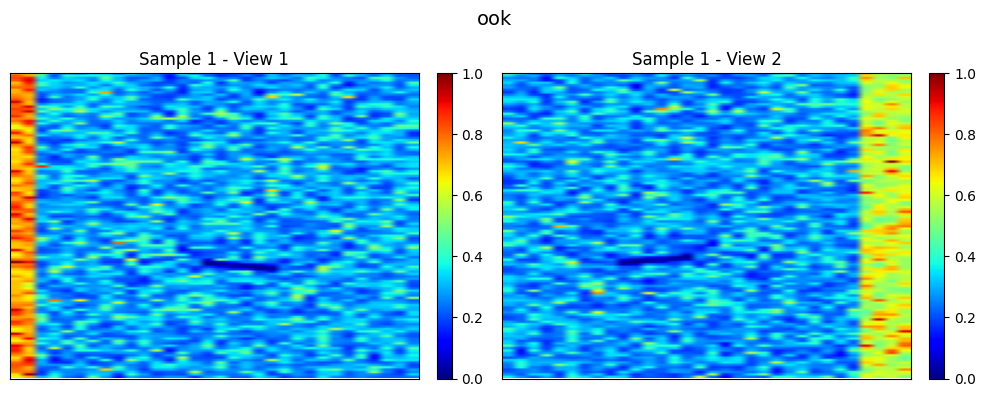

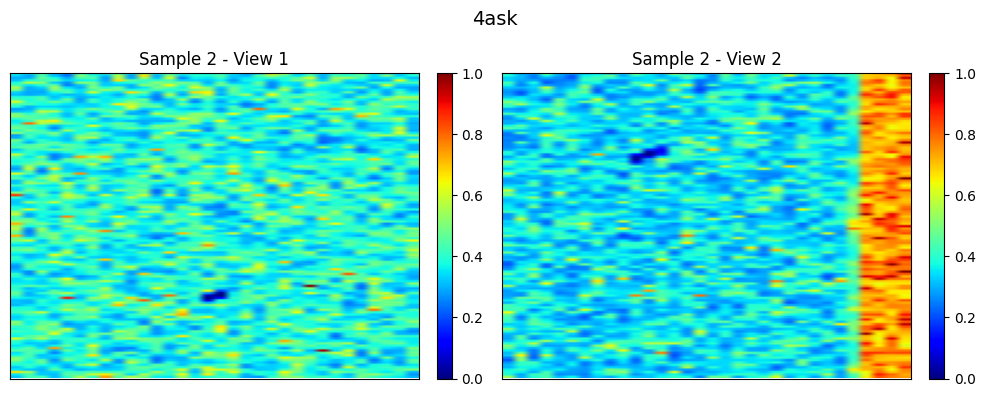

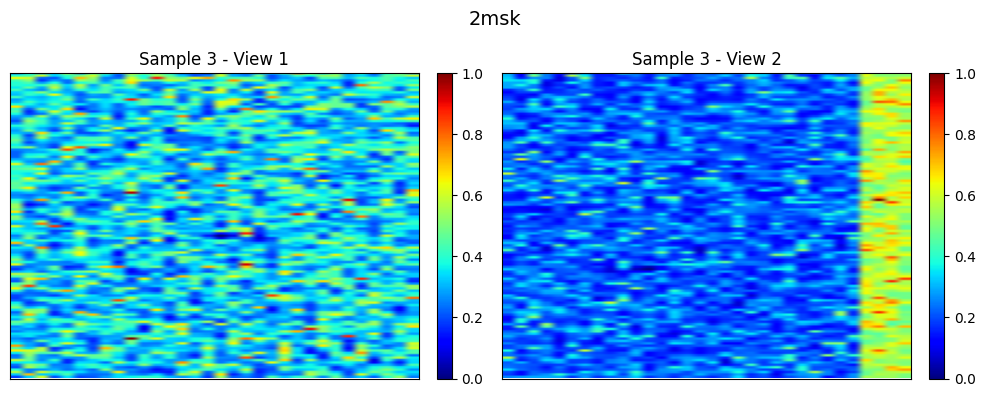

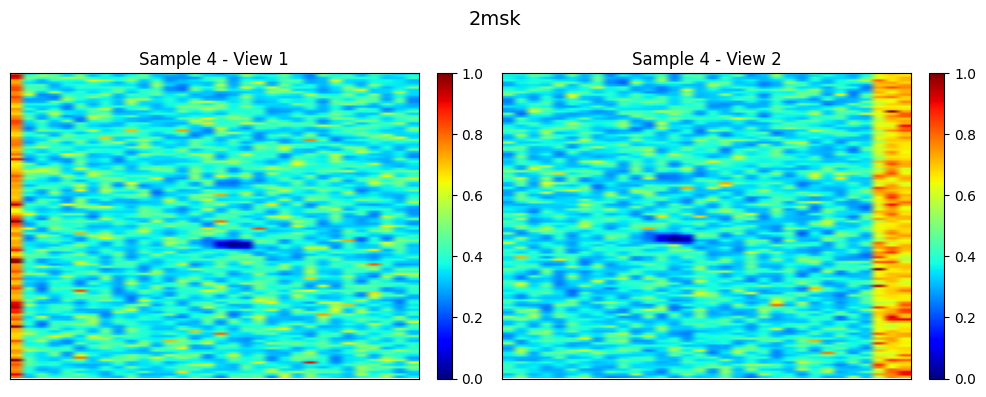

In [9]:
loader = datamodule.train_dataloader()
batch = next(iter(loader))
print("📊 Sample Metadata for Inspection:")
import json

# 🔁 Load feature vectors once
with open("/home/airbus/selfRF/datasets/NARROWBAND_ZARR/feature_vectors.json", "r") as f:
    feature_vectors = json.load(f)

raw_dataset = datamodule.train_dataset

print("📊 Matched Sample Metadata:")
for i in range(4):  # visualize samples 1–4
    signal, meta_tuple = raw_dataset[i]
    class_index = meta_tuple[0][0]
    class_name = meta_tuple[1][0]

    # ✅ Match by sample index, not class_index
    fv = feature_vectors[i]

    print(f"🧩 Sample {i+1}: Class Index {class_index} ({class_name})")
    print("  Bandwidth      :", fv.get("original_bandwidth"))
    print("  Duration       :", fv.get("duration"))
    print("  Center Freq    :", fv.get("original_center_freq"))
    print("-" * 40)


visualize_batch(batch, mode="spectrogram")